# Machine Learning Model Reasoning
This notebook visualizes the reasoning behind the Cost Prediction Model. We will look at feature importances, actual vs predicted values, residual plots, and how certain features affect the model's predictions.

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Set plotting style
sns.set_theme(style="whitegrid")

# Load the data
df = pd.read_csv('pipeline_cost_output.csv')

# Load the encoder and decode the vehicle type
veh_type_encoder = joblib.load('exported/veh_type_encoder.pkl')
df['vehicle_type_name'] = veh_type_encoder.inverse_transform(df['vehicle_type_encoded'])
df.head()

,estimated_duration_mins,actual_amount,service_id,base_price,base_duration_hours,is_price_fixed,vehicle_age,vehicle_type_encoded,actual_duration_mins,predicted_duration_mins,predicted_amount,vehicle_type_name
0,114.983333,2248.22,2134,7100.08,1.25,0,15.0,3,113.416667,120.510833,4863.1880,SUV
1,193.333333,1096.06,2131,5269.58,1.22,1,16.0,0,181.516667,185.936333,2406.2485,Crossover
2,131.000000,1372.85,2138,5565.99,4.71,0,3.0,5,147.416667,147.300333,2848.9621,Van
3,98.183333,1145.70,2156,1919.78,4.28,0,6.0,0,101.500000,128.187667,2240.0857,Crossover
4,62.900000,7999.14,2134,7100.08,1.25,0,15.0,3,80.650000,76.126667,6918.3956,SUV


## 1. Actual vs Predicted Cost
Let's see how well the model's predictions align with the actual costs.

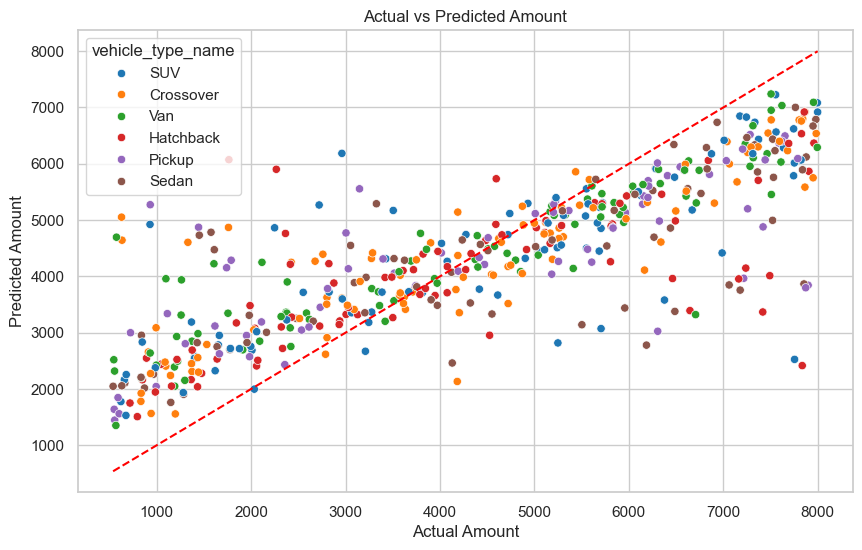

In [72]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='actual_amount', y='predicted_amount', data=df, alpha=1, hue='vehicle_type_name', palette='tab10')
plt.plot([df['actual_amount'].min(), df['actual_amount'].max()], 
         [df['actual_amount'].min(), df['actual_amount'].max()], 
         color='red', linestyle='--')
plt.title('Actual vs Predicted Amount')
plt.xlabel('Actual Amount')
plt.ylabel('Predicted Amount')
plt.show()

## 2. Residual Analysis
Plotting the residuals (Actual - Predicted) helps us identify if there are any patterns the model is missing.

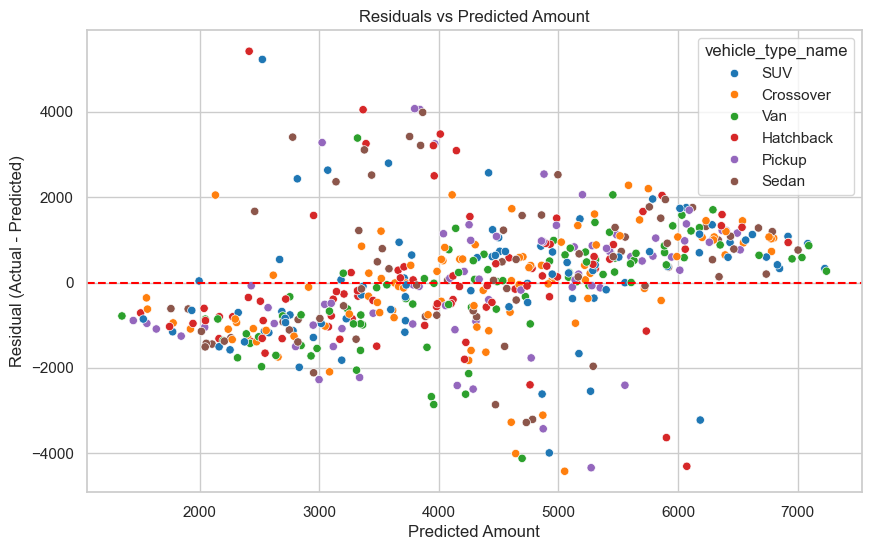

In [73]:
df['residual'] = df['actual_amount'] - df['predicted_amount']

plt.figure(figsize=(10, 6))
sns.scatterplot(x='predicted_amount', y='residual', data=df, alpha=1, hue='vehicle_type_name', palette='tab10')
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Predicted Amount')
plt.xlabel('Predicted Amount')
plt.ylabel('Residual (Actual - Predicted)')
plt.show()

## 3. Feature Importances
Let's load the exported model and see which features it considers most important.

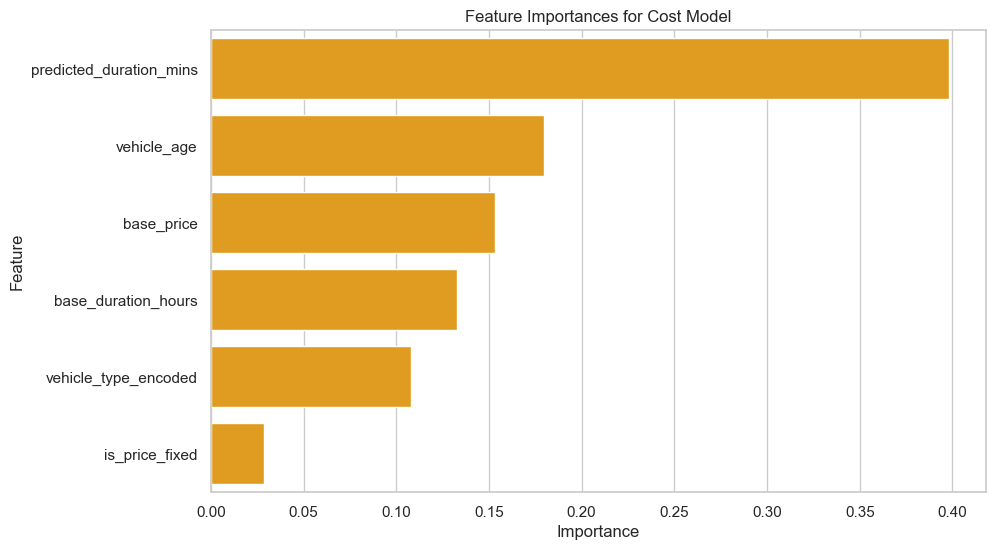

In [90]:
try:
    rf_cost = joblib.load('exported/cost_model.pkl')
    features = ['predicted_duration_mins', 'base_price', 'base_duration_hours',
                'is_price_fixed', 'vehicle_age', 'vehicle_type_encoded']
    
    importances = rf_cost.feature_importances_
    feat_imp = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feat_imp, color='orange')
    plt.title('Feature Importances for Cost Model')
    plt.show()
except Exception as e:
    print("Could not load model to show feature importances:", e)

## 4. How Features Affect Cost
We can look at boxplots and scatter plots to understand the relationship between key features and the cost.

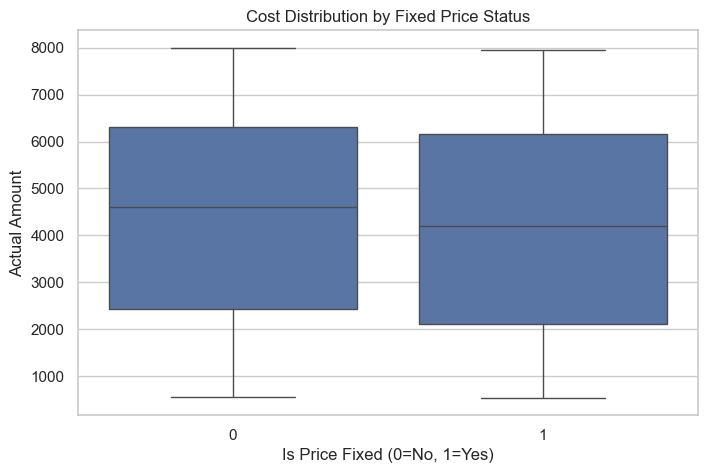

In [75]:
# Boxplot for Fixed Price vs Cost
plt.figure(figsize=(8, 5))
sns.boxplot(x='is_price_fixed', y='actual_amount', data=df)
plt.title('Cost Distribution by Fixed Price Status')
plt.xlabel('Is Price Fixed (0=No, 1=Yes)')
plt.ylabel('Actual Amount')
plt.show()

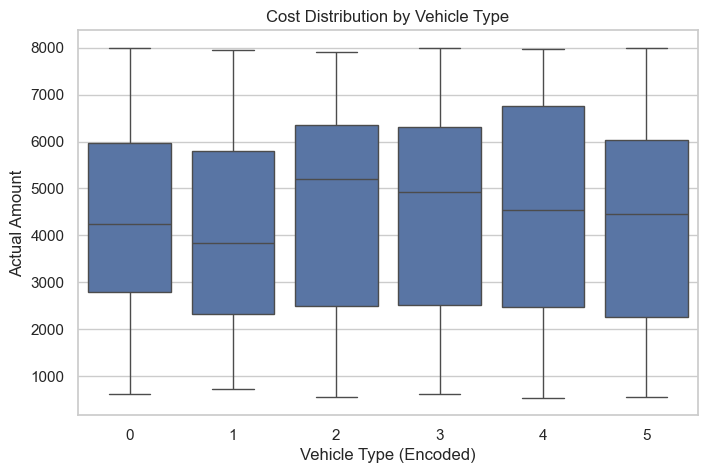

In [76]:
# Boxplot for Vehicle Type vs Cost
plt.figure(figsize=(8, 5))
sns.boxplot(x='vehicle_type_encoded', y='actual_amount', data=df)
plt.title('Cost Distribution by Vehicle Type')
plt.xlabel('Vehicle Type (Encoded)')
plt.ylabel('Actual Amount')
plt.show()

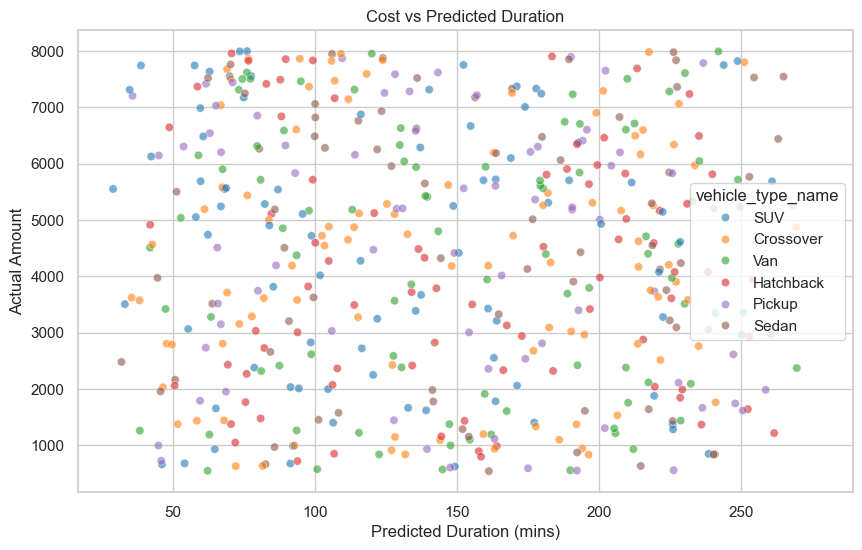

In [77]:
# Scatter plot for Predicted Duration vs Cost
plt.figure(figsize=(10, 6))
sns.scatterplot(x='predicted_duration_mins', y='actual_amount', data=df, alpha=0.6, hue='vehicle_type_name', palette='tab10')
plt.title('Cost vs Predicted Duration')
plt.xlabel('Predicted Duration (mins)')
plt.ylabel('Actual Amount')
plt.show()

## 5. Estimated vs Actual vs Predicted Duration
A boxplot comparing the distribution of the estimated, actual, and predicted duration values. Data points are displayed over the boxes to show the exact spread.

C:\Users\Snow\AppData\Local\Temp\ipykernel_26284\1900101166.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Type', y='Duration (mins)', data=df_time, palette='Set2', showfliers=False)


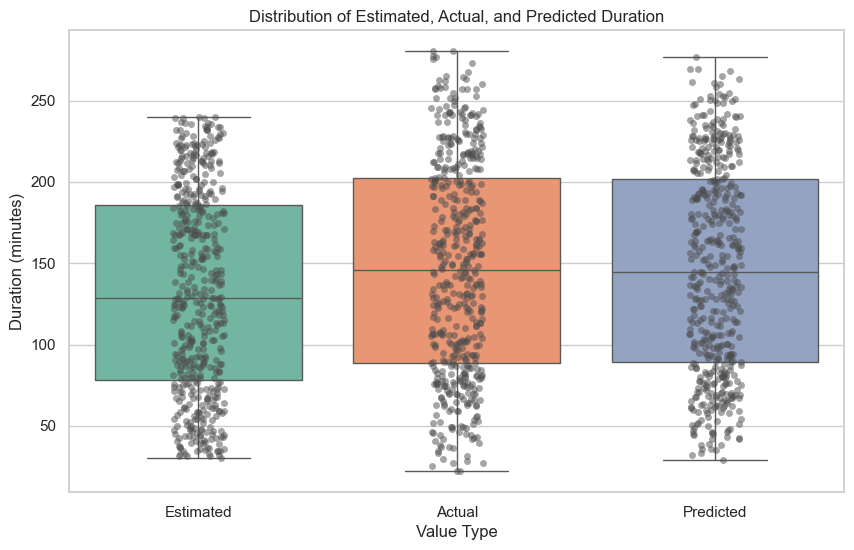

In [78]:
df_time = df[['estimated_duration_mins', 'actual_duration_mins', 'predicted_duration_mins']].melt(
    var_name='Type', value_name='Duration (mins)')
df_time['Type'] = df_time['Type'].replace({
    'estimated_duration_mins': 'Estimated',
    'actual_duration_mins': 'Actual',
    'predicted_duration_mins': 'Predicted'
})

plt.figure(figsize=(10, 6))
ax = sns.boxplot(x='Type', y='Duration (mins)', data=df_time, palette='Set2', showfliers=False)
sns.stripplot(x='Type', y='Duration (mins)', data=df_time, color='.3', alpha=0.5, jitter=True)
plt.title('Distribution of Estimated, Actual, and Predicted Duration')
plt.ylabel('Duration (minutes)')
plt.xlabel('Value Type')
plt.show()

## 6. Base Price vs Actual vs Predicted Cost
A boxplot comparing the distribution of the base price (estimated cost), actual amount, and predicted amount. Data points are displayed over the boxes to show the exact spread.

C:\Users\Snow\AppData\Local\Temp\ipykernel_26284\4067967257.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Type', y='Amount', data=df_cost, palette='Set3', showfliers=False)


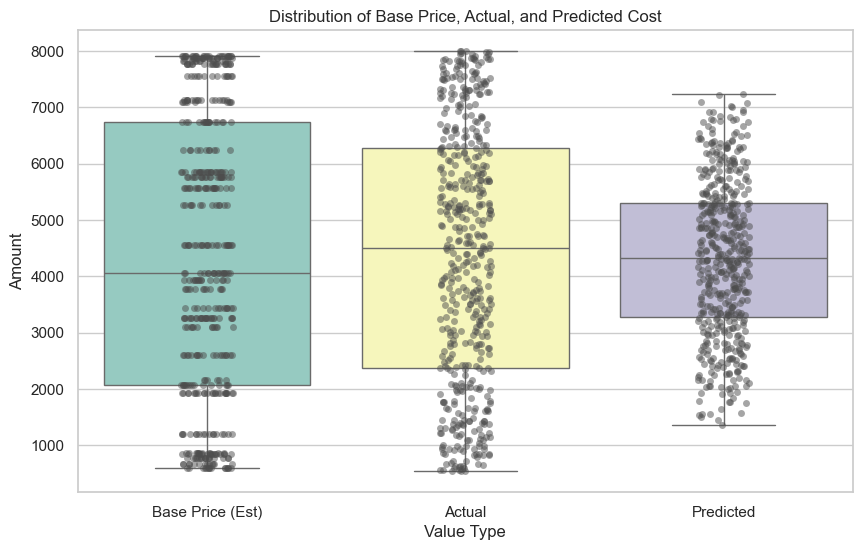

In [79]:
df_cost = df[['base_price', 'actual_amount', 'predicted_amount']].melt(
    var_name='Type', value_name='Amount')
df_cost['Type'] = df_cost['Type'].replace({
    'base_price': 'Base Price (Est)',
    'actual_amount': 'Actual',
    'predicted_amount': 'Predicted'
})

plt.figure(figsize=(10, 6))
ax = sns.boxplot(x='Type', y='Amount', data=df_cost, palette='Set3', showfliers=False)
sns.stripplot(x='Type', y='Amount', data=df_cost, color='.3', alpha=0.5, jitter=True)
plt.title('Distribution of Base Price, Actual, and Predicted Cost')
plt.ylabel('Amount')
plt.xlabel('Value Type')
plt.show()

## 7. Summary Statistics (Mean & Median)
Here we calculate the exact mean and median values for both Time and Cost to complement the boxplots above.

In [83]:
print("--- TIME (Duration in mins) ---")
print(f"Estimated = Mean: {df['estimated_duration_mins'].mean():.2f}, Median: {df['estimated_duration_mins'].median():.2f}")
print(f"Actual =  Mean: {df['actual_duration_mins'].mean():.2f}, Median: {df['actual_duration_mins'].median():.2f}")
print(f"Predicted = Mean: {df['predicted_duration_mins'].mean():.2f}, Median: {df['predicted_duration_mins'].median():.2f}\n")

print("--- COST (Amount) ---")
print(f"Base Est = Mean: {df['base_price'].mean():.2f}, Median: {df['base_price'].median():.2f}")
print(f"Actual =  Mean: {df['actual_amount'].mean():.2f}, Median: {df['actual_amount'].median():.2f}")
print(f"Predicted = Mean: {df['predicted_amount'].mean():.2f}, Median: {df['predicted_amount'].median():.2f}")


--- TIME (Duration in mins) ---
Estimated = Mean: 132.14, Median: 128.30
Actual =  Mean: 146.96, Median: 145.67
Predicted = Mean: 146.38, Median: 144.29

--- COST (Amount) ---
Base Est = Mean: 4381.62, Median: 4058.19
Actual =  Mean: 4360.75, Median: 4507.19
Predicted = Mean: 4327.80, Median: 4318.32


## 2. Cost & Time Estimation Metrics
Random Forest Regression pipeline established to estimate total quotation costs based on services and required parts.

In [89]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

# Load cost model and data
rf_cost = joblib.load('exported/cost_model.pkl')
features_cost = ['predicted_duration_mins', 'base_price', 'base_duration_hours', 'is_price_fixed', 'vehicle_age', 'vehicle_type_encoded']
X_cost = df[features_cost]
y_cost = df['actual_amount']

# Get predictions
y_pred = rf_cost.predict(X_cost)

# Calculate metrics
mse = mean_squared_error(y_cost, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_cost, y_pred)
r2 = r2_score(y_cost, y_pred)

print("Cost Estimation Metrics:")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R²:   {r2:.4f}")

# Calculate metrics for Time Estimation
y_true_time = df['actual_duration_mins']
y_pred_time = df['predicted_duration_mins']

mse_time = mean_squared_error(y_true_time, y_pred_time)
rmse_time = np.sqrt(mse_time)
mae_time = mean_absolute_error(y_true_time, y_pred_time)
r2_time = r2_score(y_true_time, y_pred_time)

print("\nTime Estimation Metrics: ")
print(f"MSE: {mse_time:.2f}")
print(f"RMSE: {rmse_time:.2f} mins")
print(f"MAE: {mae_time:.2f} mins")
print(f"R²: {r2_time:.4f}")

Cost Estimation Metrics:
MSE:  1965253.68
RMSE: 1401.88
MAE:  1061.88
R²:   0.6140

Time Estimation Metrics: 
MSE: 117.68
RMSE: 10.85 mins
MAE: 8.23 mins
R²: 0.9726


## 3. Churn Classifier
Classification model configured using probability outputs (type="prob") to calculate churn risk percentages. Confusion matrix and ROC-AUC curve evaluation complete.

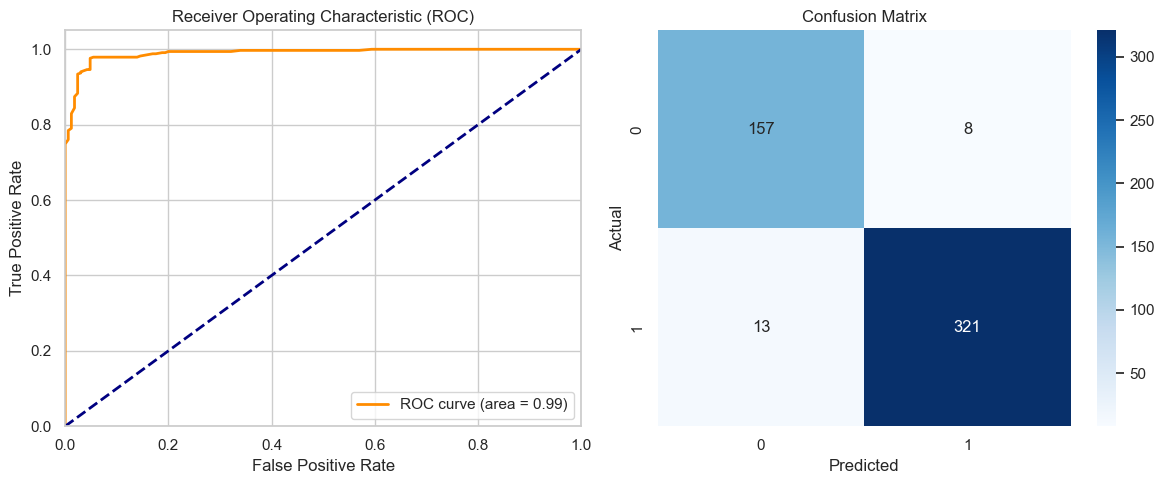

In [82]:
from sklearn.metrics import confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# Recreate churn target identically to run_churn.py
np.random.seed(42)
churn_prob = (
    (df['predicted_duration_mins'] / df['predicted_duration_mins'].max()) * 0.4
    + (df['predicted_amount'] / df['predicted_amount'].max()) * 0.4
    + np.random.uniform(0, 0.2, size=len(df))
)
df['is_churned'] = (churn_prob > 0.5).astype(int)

# Load churn model
rf_churn = joblib.load('exported/churn_model.pkl')
features_churn = ['predicted_duration_mins', 'predicted_amount', 'base_price', 'base_duration_hours', 'vehicle_age', 'vehicle_type_encoded']
X_churn = df[features_churn]
y_churn = df['is_churned']

# Get probabilities (type="prob") and predictions
y_prob = rf_churn.predict_proba(X_churn)[:, 1]
y_pred = rf_churn.predict(X_churn)

# Plot ROC-AUC
fpr, tpr, _ = roc_curve(y_churn, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")

# Plot Confusion Matrix
plt.subplot(1, 2, 2)
cm = confusion_matrix(y_churn, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.tight_layout()
plt.show()


## Time Estimation Evaluation
Now, let's evaluate the performance of the **Time Estimation** model. We will calculate the Mean Squared Error (MSE), Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and R-squared (R²) score by comparing `actual_duration_mins` and `predicted_duration_mins`.

## Actual vs Predicted Duration (Time)
Let's apply the same visual analysis to the Time Estimation model to see how predicted duration aligns with the actual duration, as well as checking the residuals.

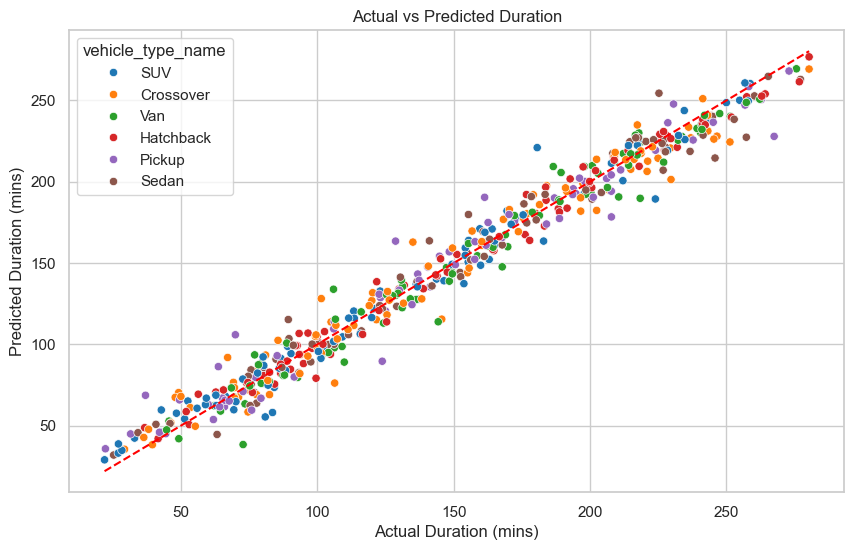

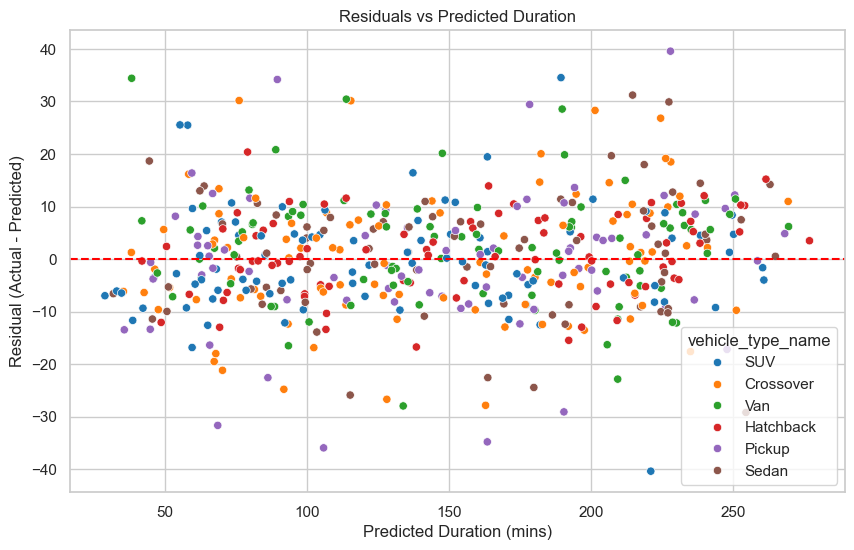

In [92]:
# Actual vs Predicted Time
plt.figure(figsize=(10, 6))
sns.scatterplot(x='actual_duration_mins', y='predicted_duration_mins', data=df, alpha=1, hue='vehicle_type_name', palette='tab10')
plt.plot([df['actual_duration_mins'].min(), df['actual_duration_mins'].max()], 
         [df['actual_duration_mins'].min(), df['actual_duration_mins'].max()], 
         color='red', linestyle='--')
plt.title('Actual vs Predicted Duration')
plt.xlabel('Actual Duration (mins)')
plt.ylabel('Predicted Duration (mins)')
plt.show()

# Residuals vs Predicted Time
df['residual_time'] = df['actual_duration_mins'] - df['predicted_duration_mins']

plt.figure(figsize=(10, 6))
sns.scatterplot(x='predicted_duration_mins', y='residual_time', data=df, alpha=1, hue='vehicle_type_name', palette='tab10')
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Predicted Duration')
plt.xlabel('Predicted Duration (mins)')
plt.ylabel('Residual (Actual - Predicted)')
plt.show()


## Feature Importances for Time Estimation
What are the main drivers of service duration? Let's analyze the feature importances extracted directly from the random forest model.

C:\Users\Snow\AppData\Local\Temp\ipykernel_26284\4235806185.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_time, palette='plasma')


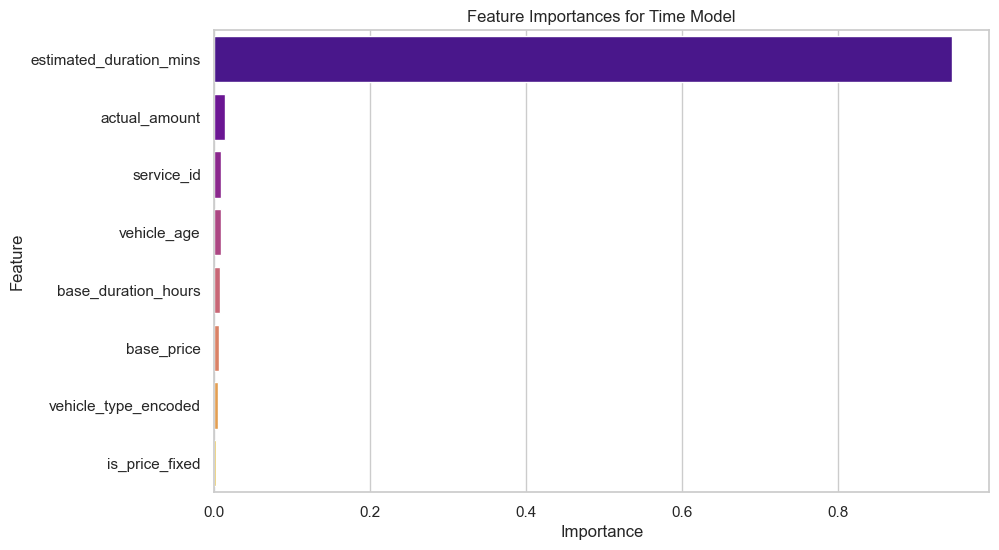

In [93]:
try:
    rf_time = joblib.load('exported/time_model.pkl')
    features_time = ['estimated_duration_mins', 'actual_amount', 'service_id',
                     'base_price', 'base_duration_hours', 'is_price_fixed',
                     'vehicle_age', 'vehicle_type_encoded']
    
    importances_time = rf_time.feature_importances_
    feat_imp_time = pd.DataFrame({'Feature': features_time, 'Importance': importances_time}).sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feat_imp_time, palette='plasma')
    plt.title('Feature Importances for Time Model')
    plt.show()
except Exception as e:
    print("Could not load time model to show feature importances:", e)
